# 01 - Exploratory Data Analysis

Rossmann runs a chain of drugstores. The company needs a daily sales forecast
for each store, so that it can plan its staff and its stock. This notebook
looks at the historical data. We want to understand what drives sales before
we build any model.

We read the data with `DataLoader`. It joins the store facts to the daily rows
and repairs the type problem in `StateHoliday`. First we load the **raw** data,
with the closed days still inside, and we check it. Only after that do we
remove the closed days. All the data work uses Polars.

In [1]:
import sys
from datetime import date
from pathlib import Path

import polars as pl
import matplotlib.pyplot as plt

# Make the src package importable when the notebook runs from notebooks/.
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader

SEED = 42

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

# Raw load keeps closed days so we can validate before dropping anything.
df_raw = DataLoader(PROJECT_ROOT / "data").load(drop_closed=False)
print("Raw rows (closed days included):", df_raw.height)
df_raw.head()

Raw rows (closed days included): 1017209


Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
i64,i64,date,i64,i64,i64,i64,str,i64,str,str,i64,i64,i64,i64,i64,i64,str
1,2,2013-01-01,0,0,0,0,"""a""",1,"""c""","""a""",1270,9,2008,0,null,null,""""""
1,3,2013-01-02,5530,668,1,0,"""0""",1,"""c""","""a""",1270,9,2008,0,null,null,""""""
1,4,2013-01-03,4327,578,1,0,"""0""",1,"""c""","""a""",1270,9,2008,0,null,null,""""""
1,5,2013-01-04,4486,619,1,0,"""0""",1,"""c""","""a""",1270,9,2008,0,null,null,""""""
1,6,2013-01-05,4997,635,1,0,"""0""",1,"""c""","""a""",1270,9,2008,0,null,null,""""""


## Data validation

Before we drop or change anything, we check the raw data for problems: the
range of the values, rows that contradict each other, the dates, the join with
the store table, and the store facts themselves. A `[!!]` marks a check that
found rows we should look at.

In [2]:
def check(label, bad_count):
    flag = "OK" if bad_count == 0 else "!!"
    print(f"[{flag}] {label}: {bad_count}")

# Row-level checks on the daily table.
print("--- Value ranges ---")
check("DayOfWeek outside 1..7", df_raw.filter(~pl.col("DayOfWeek").is_between(1, 7)).height)
check("StateHoliday not in {0,a,b,c}", df_raw.filter(~pl.col("StateHoliday").is_in(["0", "a", "b", "c"])).height)
check("Sales < 0", df_raw.filter(pl.col("Sales") < 0).height)
check("Customers < 0", df_raw.filter(pl.col("Customers") < 0).height)

print("--- Cross-field: Open / Sales / Customers ---")
check("Open==0 but Sales>0", df_raw.filter((pl.col("Open") == 0) & (pl.col("Sales") > 0)).height)
check("Open==0 but Customers>0", df_raw.filter((pl.col("Open") == 0) & (pl.col("Customers") > 0)).height)
check("Sales>0 but Customers==0", df_raw.filter((pl.col("Sales") > 0) & (pl.col("Customers") == 0)).height)
check("Customers>0 but Sales==0", df_raw.filter((pl.col("Customers") > 0) & (pl.col("Sales") == 0)).height)
print("     (info) Open==1 & Sales==0 (open, no sales):",
      df_raw.filter((pl.col("Open") == 1) & (pl.col("Sales") == 0)).height)

print("--- Date & join integrity ---")
check("DayOfWeek != actual weekday(Date)", df_raw.filter(pl.col("DayOfWeek") != pl.col("Date").dt.weekday()).height)
check("Duplicate (Store, Date)", df_raw.group_by(["Store", "Date"]).len().filter(pl.col("len") > 1).height)
check("Rows with null StoreType after join", df_raw.filter(pl.col("StoreType").is_null()).height)

--- Value ranges ---
[OK] DayOfWeek outside 1..7: 0
[OK] StateHoliday not in {0,a,b,c}: 0
[OK] Sales < 0: 0
[OK] Customers < 0: 0
--- Cross-field: Open / Sales / Customers ---
[OK] Open==0 but Sales>0: 0
[OK] Open==0 but Customers>0: 0
[OK] Sales>0 but Customers==0: 0
[!!] Customers>0 but Sales==0: 2
     (info) Open==1 & Sales==0 (open, no sales): 54
--- Date & join integrity ---
[OK] DayOfWeek != actual weekday(Date): 0
[OK] Duplicate (Store, Date): 0
[OK] Rows with null StoreType after join: 0


The daily table is consistent. The categories are valid, there are no negative
values, and no rows contradict each other. A closed day always has zero sales
and zero customers, so "closed" really means closed. There are two small
exceptions with customers but no sales, and 54 open days with zero sales. We
leave both out of the metrics later, so they do not affect our work. Every
store in the daily data also exists in the store table, so no join fails.

In [3]:
# Store-level checks on the metadata (one row per store).
stores = df_raw.unique(subset="Store")
print("Distinct stores:", stores.height)

print("--- Missing metadata (legitimate, handled in FeatureBuilder) ---")
check("CompetitionDistance null", stores.filter(pl.col("CompetitionDistance").is_null()).height)
print("     CompetitionOpenSince* null:",
      stores.filter(pl.col("CompetitionOpenSinceYear").is_null()).height, "stores")
print("     Promo2 disabled (SinceWeek null):",
      stores.filter(pl.col("Promo2SinceWeek").is_null()).height, "stores")

print("--- Promo2 logic consistency ---")
p2_off = stores.filter(pl.col("Promo2") == 0)
p2_on = stores.filter(pl.col("Promo2") == 1)
check("Promo2==0 but a since-field is set",
      p2_off.filter(pl.col("Promo2SinceWeek").is_not_null()).height)
check("Promo2==1 but a since-field is missing",
      p2_on.filter(pl.col("Promo2SinceWeek").is_null()).height)

print("--- Competition open year sanity ---")
oldest = (stores.filter(pl.col("CompetitionOpenSinceYear").is_not_null())
          .group_by("CompetitionOpenSinceYear").len()
          .sort("CompetitionOpenSinceYear").head(3))
print(oldest)
check("CompetitionOpenSinceYear < 1950 (suspect placeholder)",
      stores.filter(pl.col("CompetitionOpenSinceYear") < 1950).height)

Distinct stores: 1115
--- Missing metadata (legitimate, handled in FeatureBuilder) ---
[!!] CompetitionDistance null: 3
     CompetitionOpenSince* null: 354 stores
     Promo2 disabled (SinceWeek null): 544 stores
--- Promo2 logic consistency ---
[OK] Promo2==0 but a since-field is set: 0
[OK] Promo2==1 but a since-field is missing: 0
--- Competition open year sanity ---
shape: (3, 2)
┌──────────────────────────┬─────┐
│ CompetitionOpenSinceYear ┆ len │
│ ---                      ┆ --- │
│ i64                      ┆ u32 │
╞══════════════════════════╪═════╡
│ 1900                     ┆ 1   │
│ 1961                     ┆ 1   │
│ 1990                     ┆ 5   │
└──────────────────────────┴─────┘
[!!] CompetitionOpenSinceYear < 1950 (suspect placeholder): 1


The store facts are consistent too. The many empty values are not an error:
354 stores simply have no date for the opening of a competitor, 3 have no
distance to a competitor, and the Promo2 dates are empty exactly for the 544
stores that do not take part in Promo2.

One value looks wrong. A single store gives `CompetitionOpenSinceYear = 1900`,
which is almost certainly a placeholder. If we keep it, that store gets a
"competition age" of about 115 years, far away from every other store.
`FeatureBuilder` therefore cuts this value. The next oldest year is 1961, and
that one is believable.

## Removing closed days

In [4]:
# Validation passed, so we now drop closed days: they carry no sales signal
# and RMSPE (our main metric) divides by actual sales, so zero-sales rows
# cannot stay. The rest of the notebook uses this open-days table.
df = df_raw.filter(pl.col("Open") == 1)
print("Open-day rows:", df.height, "(removed", df_raw.height - df.height, "closed days)")
print("Stores:", df["Store"].n_unique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Open-day rows:

 844392 (removed 172817 closed days)
Stores: 1115
Date range: 2013-01-01 to 2015-07-31


We now keep one row per store for each open trading day, from January 2013 to
July 2015, for 1,115 stores. Every row that is left says something real about
demand.

## The weekly pattern

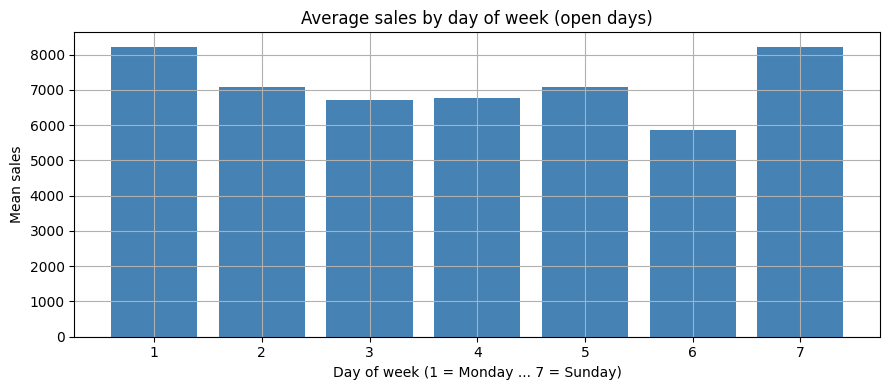

In [5]:
dow = df.group_by("DayOfWeek").agg(pl.col("Sales").mean()).sort("DayOfWeek")
plt.bar(dow["DayOfWeek"].to_list(), dow["Sales"].to_list(), color="steelblue")
plt.xlabel("Day of week (1 = Monday ... 7 = Sunday)")
plt.ylabel("Mean sales")
plt.title("Average sales by day of week (open days)")
plt.tight_layout()
plt.show()

Sales are highest at the start of the week, on Monday, and then go down slowly
towards the weekend. Sunday looks strange, because almost all stores are closed
on that day. The few stores that stay open are a special group, so we cannot
compare their average with the other days.

## The yearly pattern

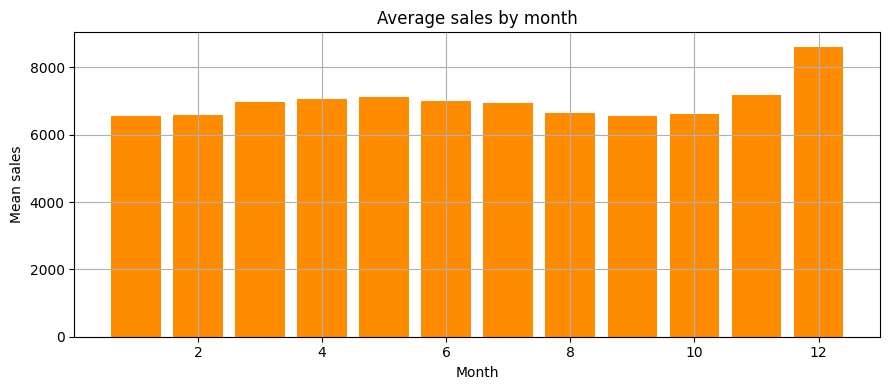

In [6]:
month = (
    df.group_by(pl.col("Date").dt.month().alias("Month"))
    .agg(pl.col("Sales").mean())
    .sort("Month")
)
plt.bar(month["Month"].to_list(), month["Sales"].to_list(), color="darkorange")
plt.xlabel("Month")
plt.ylabel("Mean sales")
plt.title("Average sales by month")
plt.tight_layout()
plt.show()

Sales reach their highest point in December, because of Christmas shopping, and
they fall in the quiet summer months. This yearly pattern is clear, and the
model should learn it from the calendar features.

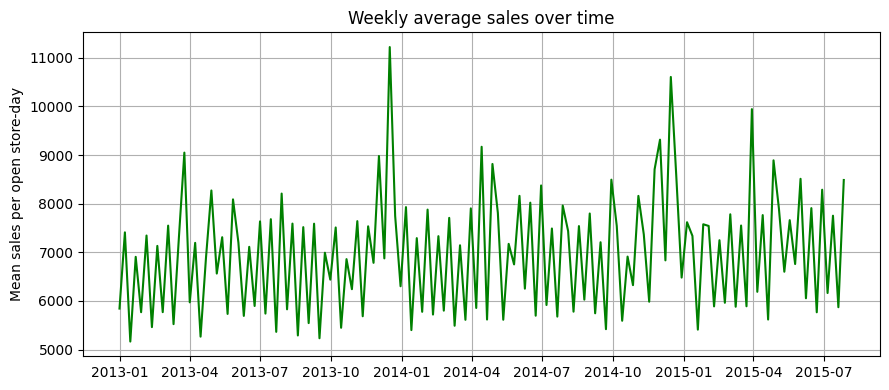

In [7]:
weekly = (
    df.sort("Date")
    .group_by_dynamic("Date", every="1w")
    .agg(pl.col("Sales").mean())
    .sort("Date")
)
plt.plot(weekly["Date"].to_list(), weekly["Sales"].to_list(), color="green")
plt.ylabel("Mean sales per open store-day")
plt.title("Weekly average sales over time")
plt.tight_layout()
plt.show()

The weekly average stays at about the same level from year to year, with a
strong peak every December. There is no big rise and no big fall over time.
This means that the changes come from the season and from the promotions, not
from the growth of the business.

## The effect of promotions

Mean sales without promo: 5929.4
Mean sales with promo:    8228.3
Promo uplift: 38.8%


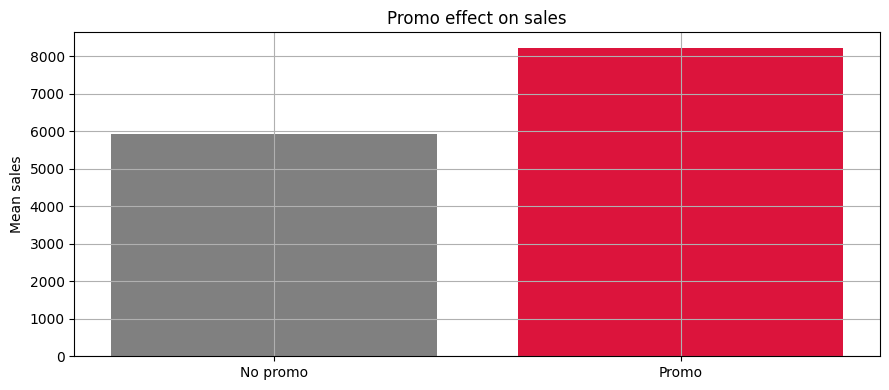

In [8]:
promo = df.group_by("Promo").agg(pl.col("Sales").mean()).sort("Promo")
no_promo = promo.filter(pl.col("Promo") == 0)["Sales"].item()
with_promo = promo.filter(pl.col("Promo") == 1)["Sales"].item()
uplift = (with_promo - no_promo) / no_promo * 100
print("Mean sales without promo:", round(no_promo, 1))
print("Mean sales with promo:   ", round(with_promo, 1))
print(f"Promo uplift: {uplift:.1f}%")

plt.bar(["No promo", "Promo"], [no_promo, with_promo], color=["gray", "crimson"])
plt.ylabel("Mean sales")
plt.title("Promo effect on sales")
plt.tight_layout()
plt.show()

Stores sell clearly more on promotion days than on normal days. The printed
number shows how large the difference is. The company plans its promotions in
advance, so we know them at prediction time. This makes `Promo` a safe and
strong feature.

## The effect of holidays

In [9]:
# StateHoliday on open days: most stores close on public holidays, so the
# a/b/c categories have few open rows. We still compare their mean sales.
state = (
    df.group_by("StateHoliday")
    .agg(pl.col("Sales").mean().alias("mean"), pl.len().alias("count"))
    .sort("StateHoliday")
)
print(state)

shape: (4, 3)
┌──────────────┬─────────────┬────────┐
│ StateHoliday ┆ mean        ┆ count  │
│ ---          ┆ ---         ┆ ---    │
│ str          ┆ f64         ┆ u32    │
╞══════════════╪═════════════╪════════╡
│ 0            ┆ 6953.515034 ┆ 843482 │
│ a            ┆ 8487.471182 ┆ 694    │
│ b            ┆ 9887.889655 ┆ 145    │
│ c            ┆ 9743.746479 ┆ 71     │
└──────────────┴─────────────┴────────┘


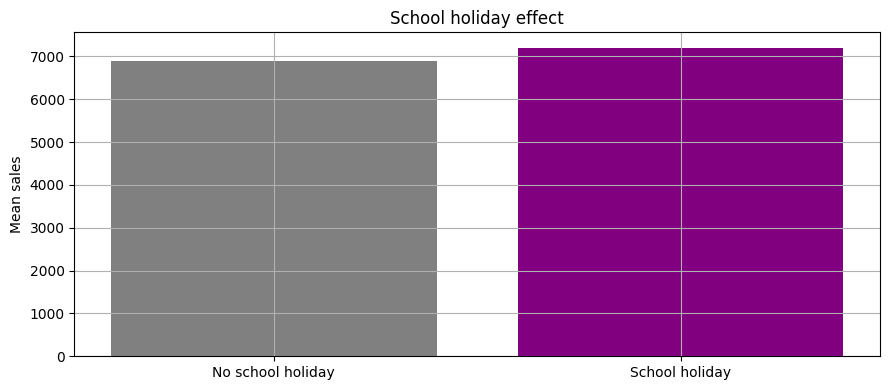

In [10]:
school = df.group_by("SchoolHoliday").agg(pl.col("Sales").mean()).sort("SchoolHoliday")
plt.bar(["No school holiday", "School holiday"], school["Sales"].to_list(),
        color=["gray", "purple"])
plt.ylabel("Mean sales")
plt.title("School holiday effect")
plt.tight_layout()
plt.show()

Public holidays (`a`, `b`, `c`) appear on very few open days, because most
stores close on those days. Their averages come from small samples, so we
should read them with care. School holidays are much more common, and they give
a small rise in sales.

## Store type and product range

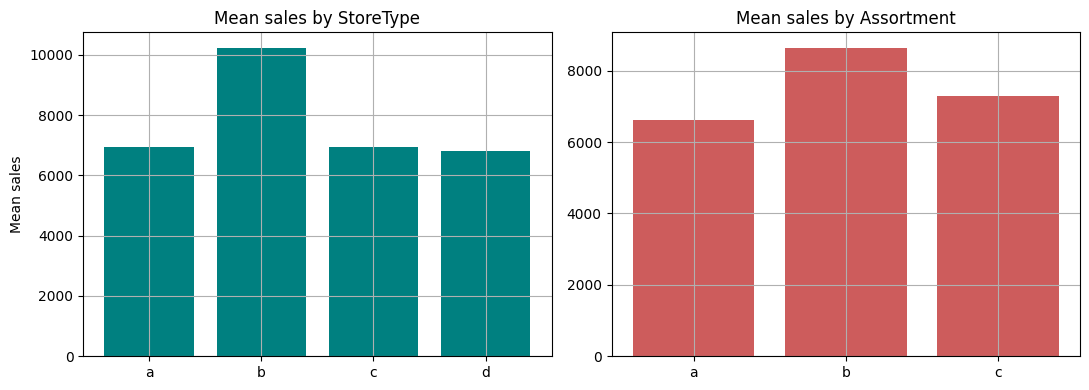

In [11]:
st = df.group_by("StoreType").agg(pl.col("Sales").mean()).sort("StoreType")
asrt = df.group_by("Assortment").agg(pl.col("Sales").mean()).sort("Assortment")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(st["StoreType"].to_list(), st["Sales"].to_list(), color="teal")
axes[0].set_title("Mean sales by StoreType")
axes[0].set_ylabel("Mean sales")
axes[1].bar(asrt["Assortment"].to_list(), asrt["Sales"].to_list(), color="indianred")
axes[1].set_title("Mean sales by Assortment")
plt.tight_layout()
plt.show()

The store types sell different amounts, and type `b` is clearly above the
others. Stores with a larger product range also tend to sell more. Both facts
stay the same over time, so the model can use them directly.

## Distance to the competitor

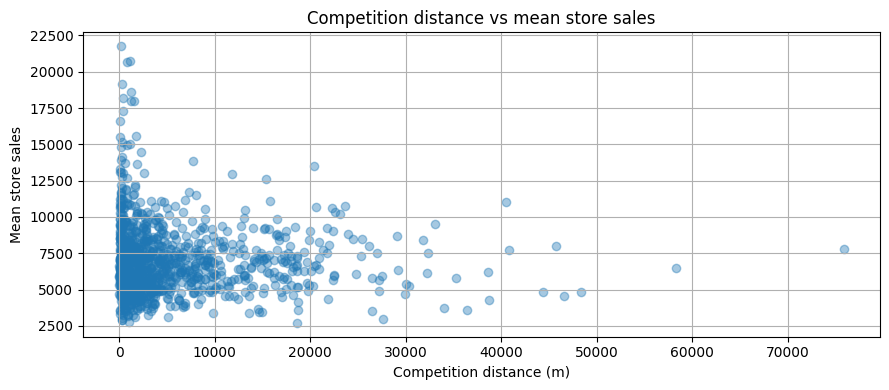

Correlation: -0.042


In [12]:
# CompetitionDistance is one value per store, so we aggregate to store level
# to avoid weighting by how many rows each store has.
store_agg = (
    df.group_by("Store")
    .agg(
        pl.col("Sales").mean().alias("MeanSales"),
        pl.col("CompetitionDistance").first().alias("CompetitionDistance"),
    )
    .drop_nulls()
)
plt.scatter(store_agg["CompetitionDistance"].to_list(),
            store_agg["MeanSales"].to_list(), alpha=0.4)
plt.xlabel("Competition distance (m)")
plt.ylabel("Mean store sales")
plt.title("Competition distance vs mean store sales")
plt.tight_layout()
plt.show()

corr = store_agg.select(pl.corr("CompetitionDistance", "MeanSales")).item()
print("Correlation:", round(corr, 3))

The link is weak. A closer competitor does not clearly mean lower sales, and a
few very isolated stores sit at the top of the range. Distance is a small
signal, not a strong driver on its own.

## Customers and sales: why we cannot use Customers

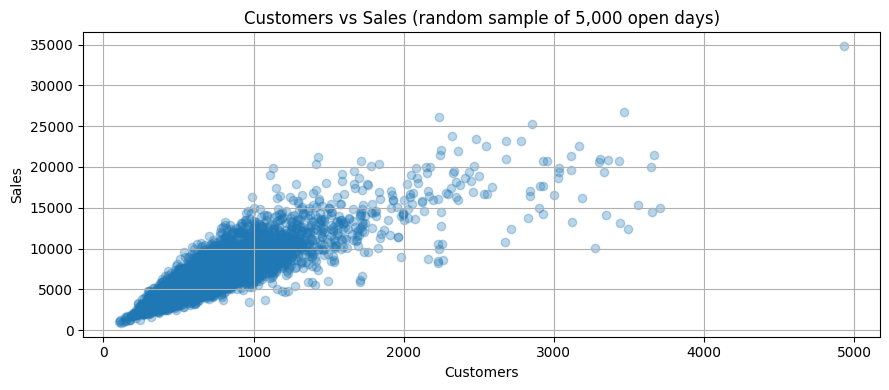

Correlation Customers-Sales: 0.824


In [13]:
sample = df.sample(n=5000, seed=SEED)
plt.scatter(sample["Customers"].to_list(), sample["Sales"].to_list(), alpha=0.3)
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales (random sample of 5,000 open days)")
plt.tight_layout()
plt.show()

corr = df.select(pl.corr("Customers", "Sales")).item()
print("Correlation Customers-Sales:", round(corr, 3))

Customers and Sales move together almost perfectly: more shoppers means more
sales. This is exactly the reason why we must **not** use `Customers` as a
feature. We do not know how many customers will come six weeks from now, so the
number is not available at prediction time. If we used it, we would give the
answer to the model and get a score that looks strong but is not real. We keep
this column for the analysis only.

## A gap in the data: store renovations in 2014

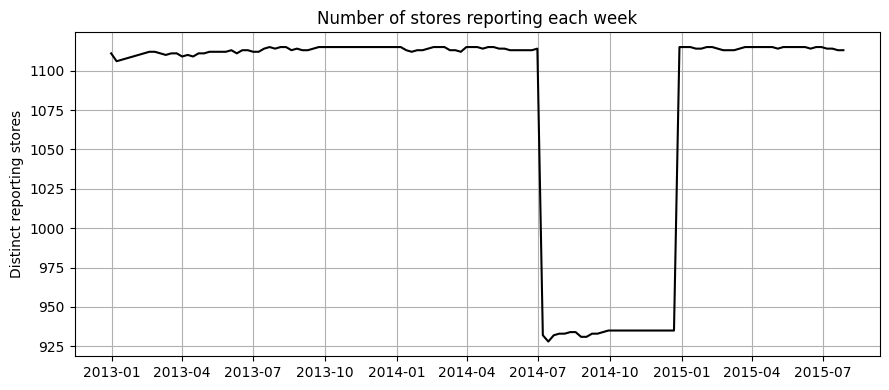

In [14]:
# Count how many distinct stores report in each week.
weekly_active = (
    df.sort("Date")
    .group_by_dynamic("Date", every="1w")
    .agg(pl.col("Store").n_unique().alias("stores"))
    .sort("Date")
)
plt.plot(weekly_active["Date"].to_list(), weekly_active["stores"].to_list(), color="black")
plt.ylabel("Distinct reporting stores")
plt.title("Number of stores reporting each week")
plt.tight_layout()
plt.show()

In [15]:
full = df["Store"].n_unique()
sep_2014 = df.filter(
    (pl.col("Date") >= date(2014, 9, 1)) & (pl.col("Date") <= date(2014, 9, 30))
)["Store"].n_unique()
print("Total stores:", full)
print("Stores active in September 2014:", sep_2014)
print("Stores missing during the gap:", full - sep_2014)

Total stores: 1115
Stores active in September 2014: 934
Stores missing during the gap: 181


About 180 stores leave the data for around six months in the second half of
2014, and then come back. These stores were closed for renovation, so their
rows are simply missing. They are not marked with `Open == 0`. This matters for
the model in two ways: those stores have less history than the others, and our
validation must not read the gap as a real fall in demand.

## Key findings

1. The data is clean. The values are in a normal range, no rows contradict each
   other, and the join with the store table works for every row. One
   competition year (1900) is a placeholder that we need to repair.
2. There is a strong weekly and yearly pattern: sales are high at the start of
   the week, and they reach their peak in December.
3. Promotions raise sales a lot, they do it reliably, and we know them in
   advance.
4. Store type and product range set the normal sales level of a store.
5. The distance to the competitor is only a weak signal.
6. `Customers` predicts sales almost perfectly, but it is leakage, so we leave
   it out of every model.
7. About 180 stores are missing around six months of 2014, because they were
   closed for renovation.